In [1]:
import numpy as np

import pandas as pd
import copy
import math
from collections import OrderedDict, Counter
#from multiprocessing import Pool
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
#from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import sympy as sp

In [2]:
_Data_PATH_XX_ = './simulation_results/'
_Figure_PATH_XX_ = './figures/'

In [3]:
N = 2000
mu = 1          #恢复速率
beta = 0.6      #传播速率与接触人数的乘积
alpha = 0.5     #防护效果
w = 1         #行为更新速率 （如果结果不稳定，可能是由于更新过快的原因）
c0 = 1          #采取防护措施的花费
cI = 6          #被感染后的代价
ita =0.001          #社会一致性的影响强度
k = 10           #每时间步平均接触人数或者网络度
gamma = 1       #由于媒体宣传，夸大感染能力或者对感染能力的误判

Init_condition_list = [[0.01, 0.05],[0.1,0.9]]

init_index = 0
#init_index = 1

n_inf = Init_condition_list[init_index][0]
n_take = Init_condition_list[init_index][1]

t_span=[0,1000]
t_eval = np.linspace(t_span[0], t_span[1], 1000000)
beta_list = [0.005 * i for i in range(200)]
cI_list = [1 + 0.1*i for i in range(100)]
alpha_list = [0.01*i for i in range(100)]
gamma_list = [0.5+0.02*i for i in range(100)]
ita_list = [0.02*i for i in range(100)]

In [4]:
filename1 = 'wellmixinf_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)
filename2 = 'wellmixtake_N'+str(N)+'k' + str(k) + '_mu'+ str(mu) + '_alpha' + str(alpha) + '_w' + str(w) + '_cI' +str(cI) +'_ita'+str(ita)+'gamma'+str(gamma)+'n_inf'+str(n_inf)+'n_take'+str(n_take)

In [5]:
#导入仿真数据
inf_ave_list = []
take_ave_list = []
beta_list_simu = []
rho_I_dict = np.load(_Data_PATH_XX_ + filename1 + '.npy',allow_pickle=True).item()
rho_take_dict = np.load(_Data_PATH_XX_ + filename2 + '.npy',allow_pickle=True).item()

for key, value in rho_I_dict.items():
    beta_list_simu.append(key)
    inf_ave_list.append(np.mean(value))

for key, value in rho_take_dict.items():
    take_ave_list.append(np.mean(value))

In [6]:
#定义演化方程
def evo_eq(t, y, w, alpha, beta, k, c0, cI, ita, mu,gamma):
    # I: 感染者比例
    # p: 易感节点中采取防护行为的比例
    I, p = y
    
    # 动力学方程 (i<2时需要停止)
    dI = -mu * I + I * (1 - I) * beta * (1 - alpha * p) * k
    
    dp = w * p * (1 - p) * (-c0 + cI*(np.exp(-(1-alpha)*beta*k*I*gamma) - np.exp(-beta*k*I*gamma)) + 2*ita*(2*p-1))
    
    return np.array([dI, dp])

In [7]:
#计算系列临界值函数及平衡点稳定性分析
#(0,0)的失稳条件
def disease_outbreak(mu,k):
    return mu/k

#(0,1)的稳定性条件：高防护初值时，疾病消失且一直采取防护措施(当且仅当2*ita>c0时存在阈值)
def disease_outbreak_with_high_ita(mu, k, alpha, ita, c0):
    if 2*ita > c0:
        thre = mu/(k*(1-alpha))
    else:
        thre = -10 #无意义
    return thre

#(0, c0+2*ita/4*ita)稳定性条件，该平衡点在c0<2*ita时才有意义, 且该平衡点始终不稳定

#（1-mu/（beta*k）, 0)稳定性：在beta>mu/k时有意义,有两个解：小值对应开始采取防护措施的临界值，大值代表低防护初值条件下灾难增长的点
def precaution_occur(mu, k, gamma, alpha, ita, c0, cI):
    
    x = sp.symbols('x')
    equation = sp.Eq(sp.exp(-(1-alpha)*x)-sp.exp(-x)-(2*ita+c0)/cI, 0)
    
    solutions = sp.solve(equation, x)
    
    print(type(solutions))
    
    thre = set()
    for z in solutions:
        thre.add((z/gamma+mu)/k)
    
    return list(thre)

#(1-mu/(beta*k(1-alpha)), 1)稳定性：在beta*k*(1-alpha)>mu时有意义，有两个解：小值对应全部采取措施的临界点；大值代表高防护初值条件下灾难式增长的点
def precaution_disappear(mu, k, gamma, alpha, ita, c0, cI):
    
    x = sp.symbols('x')
    equation = sp.Eq(sp.exp(-(1-alpha)*x)-sp.exp(-x)-(c0-2*ita)/cI, 0)
    
    solutions = sp.solve(equation, x)
    
    print(type(solutions))
    
    thre = set()
    for z in solutions:
        thre.add((z/gamma+mu/(1-alpha))/k)
    
    return list(thre)
        
thre_adopt = precaution_occur(mu, k, gamma, alpha, ita, c0, cI)
thre_nonadopt = precaution_disappear(mu, k, gamma, alpha, ita, c0, cI)
outbreak_disease_low_initial = disease_outbreak(mu,k)
outbreak_disease_high_initial = disease_outbreak_with_high_ita(mu, k, alpha, ita, c0)


print(outbreak_disease_low_initial)
print(outbreak_disease_high_initial)
print(thre_adopt)
print(thre_nonadopt)

<class 'list'>
<class 'list'>
0.1
-10
[0.147626767819087, 0.410325525493989]
[0.247333946643746, 0.511418347736000]


In [8]:
inf_ratio = {}
behavior_ratio = {}
for i in range(1):
    Init_condition = Init_condition_list[init_index]
    inf_ratio[i] = []
    behavior_ratio[i] = []
    for beta in beta_list:
    #for gamma in gamma_list:
    #for cI in cI_list:
    #for ita in ita_list:
    #for alpha in alpha_list:
        #parameters = [w, alpha, beta, k, c0, cI, ita, mu]
        #results = odeint(evo_eq, Init_condition, T, args = (parameters,))
        sol = solve_ivp(lambda t, y: evo_eq(t, y, w, alpha, beta, k, c0, cI, ita, mu,gamma), t_span, Init_condition, method='BDF',t_eval=t_eval, rtol=1e-10, atol=1e-12)
        #print(sol.y[0][-1])
        inf_ratio[i].append(sol.y[0][-1])
        behavior_ratio[i].append(sol.y[1][-1])

In [9]:
#系列临界值函数


[]

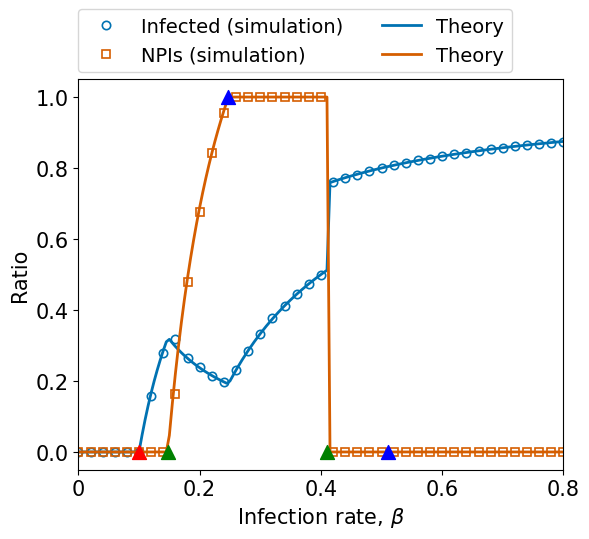

In [10]:
color_map=['#0072B2', '#D55E00', '#009E73', '#E69F00']
marker_shape = ['o','d','s','d']
plt.figure(figsize=(6,5.5))

#临界值曲线
#plt.plot([outbreak_disease_low_initial, outbreak_disease_low_initial], [0, 0.8], '--', color=color_map[0])
#plt.plot([thre_adopt[0],thre_adopt[0]], [0, 0.8], '--', color=color_map[1], label = "thre_adopt0")
#plt.plot([thre_adopt[1],thre_adopt[1]], [0, 0.8], '--', color=color_map[1], label = "thre_adopt1")
#plt.plot([thre_nonadopt[0],thre_nonadopt[0]], [0, 0.8], '--', color=color_map[2], label = "thre_nonadopt0")
#plt.plot([thre_nonadopt[1],thre_nonadopt[1]], [0, 0.8], '--', color=color_map[2], label = "thre_nonadopt1")

#plot([])
#plot([])


plt.plot(beta_list_simu, inf_ave_list,'o', markersize = 6, markerfacecolor='none',markeredgewidth=1.2, color=color_map[0], label="Infected (simulation)")
plt.plot(beta_list_simu, take_ave_list,'s', markersize = 6,markerfacecolor='none',markeredgewidth=1.2, color=color_map[1], label="NPIs (simulation)")

plt.plot(beta_list, inf_ratio[0],color=color_map[0],linewidth=2,label="Theory")
plt.plot(beta_list, behavior_ratio[0],color=color_map[1],linewidth=2,label="Theory")

posi=0
posii=1
plt.scatter(outbreak_disease_low_initial, posi, s=100, color='red',marker='^',zorder=2)
plt.scatter(thre_adopt[0], posi, s=100, color='green',marker='^',zorder=2)
plt.scatter(thre_adopt[1], posi, s=100, color='green',marker='^',zorder=2)
plt.scatter(thre_nonadopt[0], posii, s=100, color='blue',marker='^',zorder=2)
plt.scatter(thre_nonadopt[1], posi, s=100, color='blue',marker='^',zorder=2)

font1 = {'weight': 'normal','size':15}
font2 = {'weight': 'normal','size':15}
plt.legend(ncol=2, loc="upper left", bbox_to_anchor=(0, 1.18), borderaxespad=0, fontsize=14)
#plt.ylim((-0.01,1))
plt.xlim((0,0.8))
plt.xticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])
plt.subplots_adjust(left=0.19,bottom=0.17,right=0.94)
plt.tick_params(labelsize=15)
plt.xlabel('Infection rate, $\\beta$',font1)
#plt.xlabel('cI',font1)
#plt.xlabel('alpha',font1)
#plt.xlabel('gamma',font1)
#plt.xlabel('ita',font1)
plt.ylabel('Ratio',font1)

#plt.arrow(outbreak_disease_low_initial,0, 0.2, 0.3, length_includes_head=True, head_width=0.03, head_length=0.05, fc='black', ec='black')
plt.tight_layout()
plt.savefig(_Figure_PATH_XX_ + 'well-mixed_emergence_of_phenomena_' + str(init_index)+ '.png', dpi = 400)
plt.plot()


#_Data_PATH_XX_ = './data/'
#filename = 'r'+str(r)+'h'+str(h)+'v'+str(v)
#np.savetxt(_Data_PATH_XX_ + filename + '.txt', inf_number)

#phase = np.loadtxt(_Data_PATH_XX_ + filename + '.txt')
#plt.plot(beta_list,phase)